<a href="https://colab.research.google.com/github/agajinformatica/Vision_por_computadora/blob/main/S04_Caracteristicas_Segmentacion_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visión por Computadora
## Clase 4 — Características visuales y segmentación clásica
### Unidad 1 · Fundamentos y características visuales

**Laboratorio práctico (Google Colab).** En la clase anterior sacaste **bordes** con filtros que *diseñaste* tú (Sobel, Canny). Hoy das el **último paso a mano** de la Unidad 1: describir los puntos que importan (**esquinas** y **descriptores**), resumir la **forma** de un objeto (**HOG**) y **segmentar** una escena en regiones (umbral, color y watershed).

El hilo es el mismo de todo el curso: **hoy nosotros decidimos qué mirar; desde la Unidad 2, la red lo aprende sola.** Este notebook es el puente hacia ese salto.

---

#### Cómo trabajar en este notebook

1. Ejecuta las celdas **en orden**, de arriba hacia abajo, con el botón ▶ o con `Shift + Enter`.
2. Antes de correr cada celda, intenta **predecir** qué va a pasar.
3. La sección **TU TURNO**, al final, es para que completes tú sobre tu propia foto.

No necesitas instalar nada: Colab ya trae OpenCV, NumPy y Matplotlib.

---

In [1]:
# ----------------------------------------------------------------------------
# Cada 'import' trae una librería (una caja de herramientas ya hecha).
# La palabra reservada "as" le pone un apodo corto para escribir menos.
# ----------------------------------------------------------------------------
import cv2                       # OpenCV: la librería de visión por computadora
import numpy as np               # NumPy: maneja tablas de números (así se guarda una imagen)
import matplotlib.pyplot as plt  # Matplotlib: para dibujar imágenes y gráficos

# Esta línea es especial de Colab/Jupyter: hace que los gráficos aparezcan
# DENTRO del notebook, justo debajo de cada celda (y no en una ventana aparte).
%matplotlib inline

print("Todo listo. Las librerías se cargaron correctamente.")  # aviso de que ya podemos seguir

Todo listo. Las librerías se cargaron correctamente.


---

## Parte 1 — ¿Qué punto es fácil de reencontrar?

Antes de la técnica, la intuición. Una **característica** es un resumen: en vez de guardar la imagen entera, guardamos unos pocos números que capturan lo importante. El primer resumen útil son las **esquinas**. Veamos por qué una esquina es una buena "seña" y una zona plana no.

Plano    -> variación (std):   0.0
Borde    -> variación (std):  78.4
Esquina  -> variación (std):  76.8


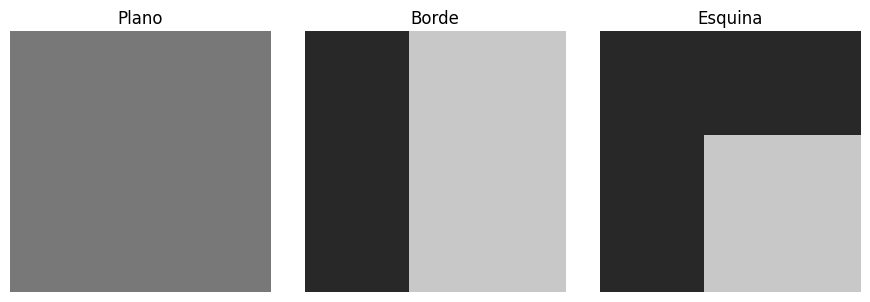

In [2]:
# Creamos tres parches de 5x5 píxeles a mano para comparar tres situaciones.
# np.full((5,5), 120) -> una tabla 5x5 llena del valor 120 (un gris medio, zona plana).
plano = np.full((5, 5), 120, dtype=np.uint8)

# np.tile repite una fila 5 veces: mitad oscura (40) y mitad clara (200) => un BORDE vertical.
borde = np.tile(np.array([40, 40, 200, 200, 200], dtype=np.uint8), (5, 1))

# Para la ESQUINA: empezamos todo oscuro (40) y aclaramos solo la esquina inferior derecha.
esquina = np.full((5, 5), 40, dtype=np.uint8)
esquina[2:, 2:] = 200          # filas 2..4 y columnas 2..4 pasan a 200 (claro)

# La "variación" (desviación estándar) mide cuánto cambian los valores dentro del parche.
for nombre, parche in [("Plano", plano), ("Borde", borde), ("Esquina", esquina)]:
    print(f"{nombre:8s} -> variación (std): {parche.std():5.1f}")

# Los dibujamos para verlos:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))            # una fila, tres columnas
for a, (nombre, parche) in zip(ax, [("Plano", plano), ("Borde", borde), ("Esquina", esquina)]):
    a.imshow(parche, cmap="gray", vmin=0, vmax=255)     # vmin/vmax fija 0=negro, 255=blanco
    a.set_title(nombre); a.axis("off")
plt.tight_layout(); plt.show()

**La idea clave del curso, aquí:** *nosotros* decidimos que una esquina es interesante y diseñamos cómo medirlo. En la Unidad 2, una CNN decidirá **sola** qué patrones vale la pena detectar, sin que se lo programemos. La operación de fondo será la misma; cambia **quién elige qué mirar**.

---

## Parte 2 — Sube tu propia imagen

En Colab la subida es un solo paso: ejecuta la celda, aparece el botón **Elegir archivos**, seleccionas tu foto y se carga. La dejamos lista en color y en grises.

Saving IMG_0199 (1).jpg to IMG_0199 (1).jpg


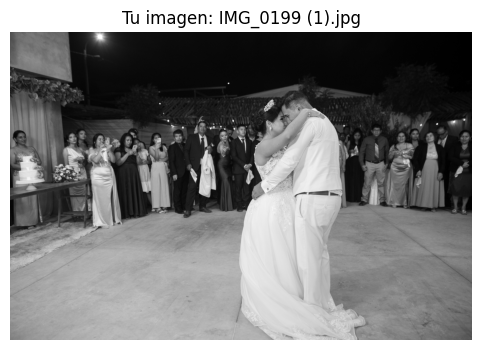

¡Listo! Tamaño (filas, columnas, canales): (3648, 5472, 3)


In [3]:
# ----------------------------------------------------------------------------
# SUBIDA DE ARCHIVO EN COLAB
# 'google.colab.files' solo existe en Colab; por eso lo importamos aquí dentro.
# ----------------------------------------------------------------------------
from google.colab import files          # herramienta de Colab para subir/bajar archivos

subidos = files.upload()                # abre el botón "Elegir archivos"; devuelve un diccionario:
                                        #   { "nombre_del_archivo": bytes_del_archivo }

work_bgr = None                          # aquí guardaremos tu imagen a color (formato BGR de OpenCV)
work_rgb = None                          # la misma imagen en RGB (para mostrarla con Matplotlib)
work_gray = None                         # y su versión en grises (para esquinas, SIFT, HOG...)

if len(subidos) == 0:                    # si no elegiste ningún archivo...
    print("No subiste ninguna imagen. Vuelve a ejecutar la celda y elige un archivo.")
else:
    nombre = list(subidos.keys())[0]     # tomamos el nombre del primer (y único) archivo
    datos = subidos[nombre]              # los bytes crudos de ese archivo

    # np.frombuffer convierte esos bytes en una lista de números (todavía no es una imagen):
    buffer = np.frombuffer(datos, dtype=np.uint8)

    # cv2.imdecode interpreta esos números y arma la imagen a color (en orden BGR de OpenCV):
    work_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)

    # OpenCV usa BGR; Matplotlib espera RGB. cv2.cvtColor convierte de uno a otro:
    work_rgb = cv2.cvtColor(work_bgr, cv2.COLOR_BGR2RGB)

    # Y una versión en grises: las esquinas, SIFT y HOG trabajan sobre una sola capa de intensidad.
    work_gray = cv2.cvtColor(work_bgr, cv2.COLOR_BGR2GRAY)

    # Mostramos tu imagen a color:
    plt.figure(figsize=(6, 4))
    plt.imshow(work_rgb)
    plt.title(f"Tu imagen: {nombre}")
    plt.axis("off")
    plt.show()
    print("¡Listo! Tamaño (filas, columnas, canales):", work_bgr.shape)

> **¿Por qué trabajaremos casi todo en grises?** Porque las esquinas, los descriptores y HOG se basan en **cambios de intensidad**, que no necesitan color. La segmentación por color (más abajo) sí usará la versión a color.

---

## Parte 3 — Esquinas con Harris

Harris recorre la imagen y en cada píxel mide cuánto cambia la intensidad al mover una ventanita en todas las direcciones. Donde cambia mucho en **todas** las direcciones, marca una esquina.

Píxeles marcados como esquina: 2651


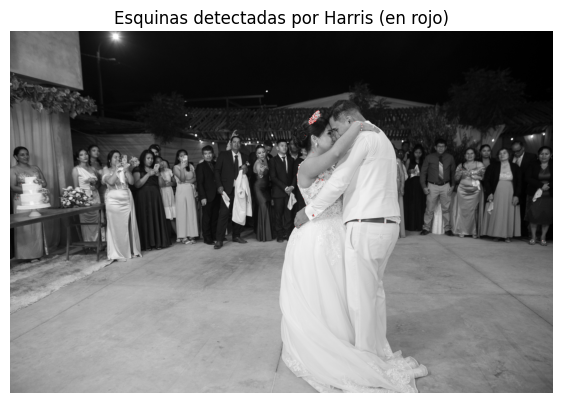

In [5]:
# Harris necesita la imagen en decimales (float32) para hacer sus cálculos internos.
gray_f = np.float32(work_gray)          # convertimos de enteros (0..255) a decimales

# cv2.cornerHarris devuelve un "mapa de esquina": un número por píxel (cuán esquina es).
#   blockSize=2 -> tamaño del vecindario que analiza en cada punto
#   ksize=3     -> apertura del operador Sobel interno (mide gradientes)
#   k=0.04      -> parámetro de sensibilidad de Harris (valor típico entre 0.04 y 0.06)
harris = cv2.cornerHarris(gray_f, blockSize=2, ksize=3, k=0.04)

# cv2.dilate engorda los puntos para que se vean mejor al pintarlos (no cambia el resultado).
harris = cv2.dilate(harris, None)

# Marcamos en ROJO los píxeles cuyo valor supera el 1% del máximo: esas son las esquinas fuertes.
img_corners = work_rgb.copy()                       # copiamos para no tocar el original
umbral = 0.05 * harris.max()                        # umbral relativo al valor más alto del mapa
img_corners[harris > umbral] = [255, 0, 0]          # esos píxeles se pintan de rojo puro

# Contamos cuántos píxeles quedaron marcados como esquina:
n_esquinas = int((harris > umbral).sum())
print("Píxeles marcados como esquina:", n_esquinas)

plt.figure(figsize=(7, 5))
plt.imshow(img_corners)
plt.title("Esquinas detectadas por Harris (en rojo)")
plt.axis("off"); plt.show()

> **Prueba a subir el umbral:** cambia el `0.01` por `0.05` y vuelve a ejecutar. Exiges esquinas más fuertes, así que se marcan **menos** puntos. Como con Canny, no hay un valor universal: depende de tu imagen.

---

## Parte 4 — Descriptores: SIFT y ORB

Detectar la esquina es la mitad; la otra mitad es **describirla** con números para reconocerla en otra foto. Comparamos dos descriptores clásicos: **SIFT** (preciso, la referencia) y **ORB** (libre y veloz).

SIFT: 7595 puntos, huella de 128 números por punto
ORB :  500 puntos, huella de 32 bytes por punto


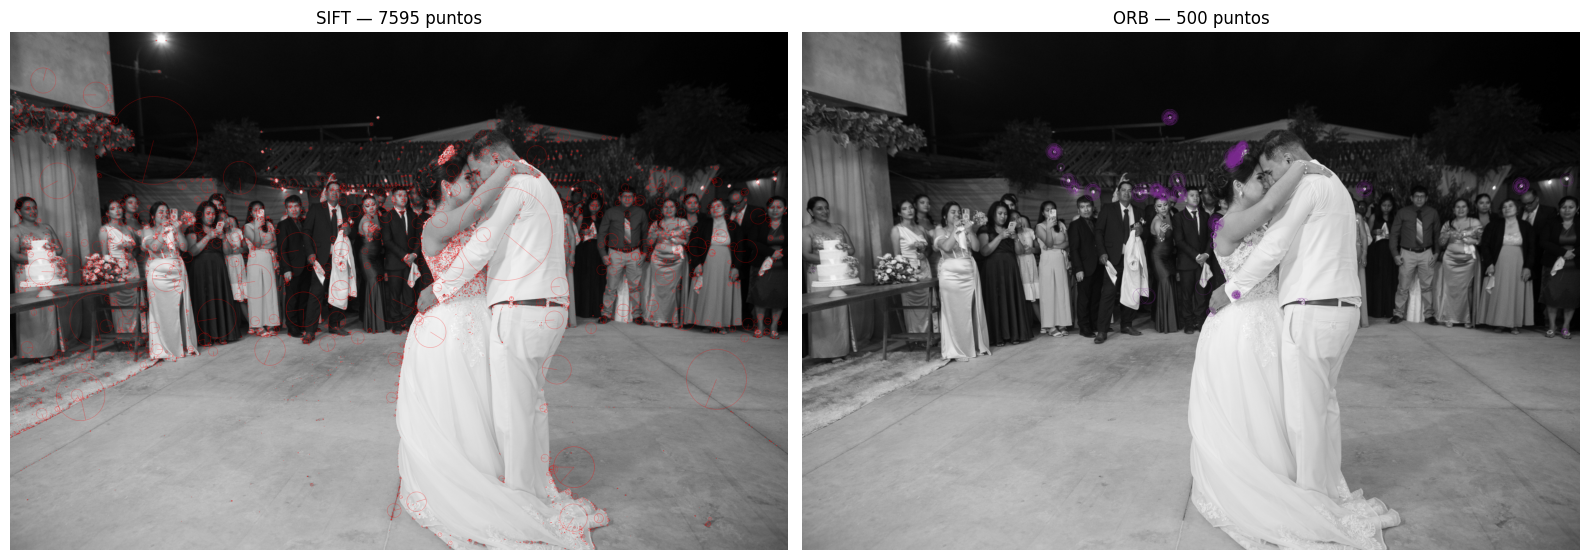

In [6]:
# --- SIFT ---
# cv2.SIFT_create() construye el detector-descriptor SIFT (libre desde OpenCV 4.4).
sift = cv2.SIFT_create()

# detectAndCompute hace las dos cosas de una vez:
#   kp  = lista de "keypoints" (los puntos interesantes que encontró)
#   des = los descriptores (la huella numérica de cada punto): una fila de 128 números por punto
kp_sift, des_sift = sift.detectAndCompute(work_gray, None)

# --- ORB ---
# cv2.ORB_create(nfeatures=500) pide hasta 500 puntos. ORB es libre y mucho más rápido.
orb = cv2.ORB_create(nfeatures=500)
kp_orb, des_orb = orb.detectAndCompute(work_gray, None)

# Cuántos puntos y de qué tamaño es la huella de cada uno:
print(f"SIFT: {len(kp_sift):4d} puntos, huella de {des_sift.shape[1] if des_sift is not None else 0} números por punto")
print(f"ORB : {len(kp_orb):4d} puntos, huella de {des_orb.shape[1] if des_orb is not None else 0} bytes por punto")

# cv2.drawKeypoints dibuja cada punto con un círculo (su escala) y una línea (su orientación).
#   flags=...RICH_KEYPOINTS hace justamente que dibuje círculo + orientación, no solo un punto.
img_sift = cv2.drawKeypoints(work_rgb, kp_sift, None, color=(255, 0, 0),
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_orb  = cv2.drawKeypoints(work_rgb, kp_orb, None, color=(120, 40, 140),
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Los mostramos lado a lado:
fig, ax = plt.subplots(1, 2, figsize=(16, 10))
ax[0].imshow(img_sift); ax[0].set_title(f"SIFT — {len(kp_sift)} puntos"); ax[0].axis("off")
ax[1].imshow(img_orb);  ax[1].set_title(f"ORB — {len(kp_orb)} puntos");   ax[1].axis("off")
plt.tight_layout(); plt.show()

**Lo que deberías notar:** SIFT suele dar puntos más finos y una huella de **128 números**; ORB da una huella **binaria de 32 bytes**, mucho más ligera y rápida de comparar. Mismo objetivo, distinto balance precisión/velocidad.

> Si `cv2.SIFT_create()` te da error, tu OpenCV es anterior a 4.4. En Colab no debería pasar; si pasa, usa solo ORB, que siempre está disponible.

---

## Parte 5 — HOG: la forma, resumida

HOG (Histograma de Gradientes Orientados) divide la imagen en celdas y, en cada una, cuenta hacia qué direcciones apuntan los bordes. Todos esos conteos juntos forman un vector que resume la **forma** del objeto.

Tamaño del vector HOG: 8100 números que resumen la forma


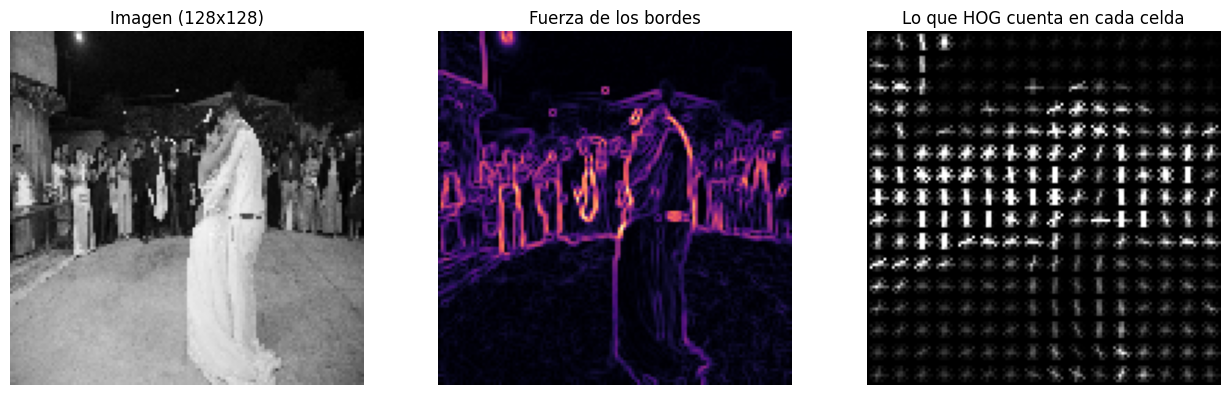

In [7]:
# Usamos la implementación de HOG de scikit-image (ya viene instalada en Colab).
# Tiene una ventaja extra: además del vector, nos DIBUJA lo que HOG cuenta en cada celda.
from skimage.feature import hog          # la función que calcula HOG
from skimage import exposure             # para ajustar el brillo del dibujo y que se vea bien

win = (128, 128)                         # tamaño de trabajo (ancho, alto)
img_hog = cv2.resize(work_gray, win)     # ajustamos tu imagen en grises a 128x128

# hog() hace los tres pasos que vimos en la diapositiva y devuelve dos cosas:
#   vector_hog -> la lista de números que resume la forma (la "huella")
#   dibujo_hog -> una imagen con la dirección dominante de los bordes en cada celda
vector_hog, dibujo_hog = hog(
    img_hog,
    orientations=9,            # cuántas direcciones distingue (9 direcciones, cada 20 grados)
    pixels_per_cell=(8, 8),    # PASO 1: tamaño de cada celda de la cuadrícula
    cells_per_block=(2, 2),    # agrupa celdas vecinas para que el brillo no afecte tanto
    visualize=True)            # pide también el dibujo, no solo el vector
print("Tamaño del vector HOG:", vector_hog.shape[0], "números que resumen la forma")

# Para comparar, calculamos también la fuerza de los bordes con Sobel:
gx = cv2.Sobel(img_hog, cv2.CV_32F, 1, 0, ksize=3)   # cambio en X (bordes verticales)
gy = cv2.Sobel(img_hog, cv2.CV_32F, 0, 1, ksize=3)   # cambio en Y (bordes horizontales)

# cv2.cartToPolar convierte (gx, gy) en magnitud (cuán fuerte es el borde) y ángulo (su dirección)
mag, ang = cv2.cartToPolar(gx, gy, angleInDegrees=True)

# rescale_intensity estira el brillo del dibujo, que sale muy tenue si no se ajusta
dibujo_hog = exposure.rescale_intensity(dibujo_hog, in_range=(0, dibujo_hog.max() / 3))

# Mostramos los tres paneles lado a lado
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(img_hog, cmap="gray");    ax[0].set_title("Imagen (128x128)")
ax[1].imshow(mag, cmap="magma");       ax[1].set_title("Fuerza de los bordes")
ax[2].imshow(dibujo_hog, cmap="gray"); ax[2].set_title("Lo que HOG cuenta en cada celda")
for a in ax: a.axis("off")               # quitamos los ejes numéricos de los tres paneles
plt.tight_layout(); plt.show()

> HOG **no guarda la imagen**: guarda cuántos bordes apuntan en cada dirección, por zona. Dos fotos distintas del mismo objeto producen vectores HOG parecidos: por eso servía para *detectar* ese objeto (por ejemplo, peatones) antes del deep learning.

---

## Parte 6 — Segmentar por brillo: umbral con Otsu

Cambiamos de pregunta: de *describir puntos* a *partir la imagen en regiones*. La vía más simple es el **umbral**: lo claro es objeto, lo oscuro es fondo. **Otsu** elige el umbral solo, mirando el histograma.

Umbral elegido por Otsu: 95.0


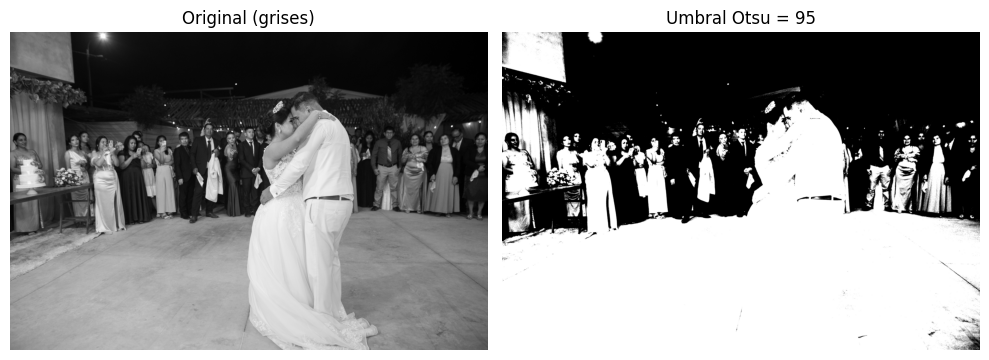

In [8]:
# cv2.threshold aplica un umbral. Al sumar cv2.THRESH_OTSU, OpenCV ELIGE el umbral automáticamente
# a partir del histograma; por eso el primer valor (0) se ignora.
#   binaria = imagen en blanco y negro (255 = objeto, 0 = fondo)
umbral_usado, binaria = cv2.threshold(work_gray, 0, 255,
                                      cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Umbral elegido por Otsu:", umbral_usado)   # el valor de corte que calculó solo

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(work_gray, cmap="gray"); ax[0].set_title("Original (grises)"); ax[0].axis("off")
ax[1].imshow(binaria, cmap="gray");   ax[1].set_title(f"Umbral Otsu = {umbral_usado:.0f}"); ax[1].axis("off")
plt.tight_layout(); plt.show()

> **Limitación:** el umbral usa un único corte global para toda la imagen. Si la iluminación es despareja (una parte en sombra), parte del objeto se confunde con el fondo. Funciona bien cuando hay buen contraste.

---

## Parte 7 — Segmentar por color: K-means

Si el objeto no se separa por brillo pero sí por **color**, agrupamos los píxeles en **K** grupos de color parecido. Cada píxel se reemplaza por el color promedio de su grupo: la imagen queda reducida a K regiones.

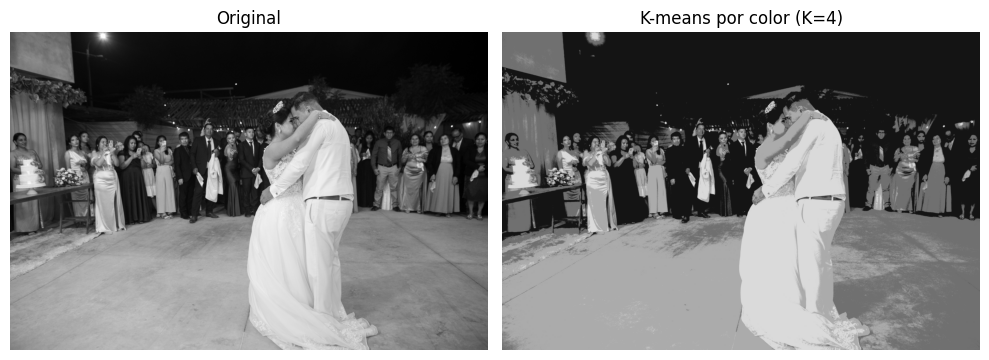

In [9]:
# Reorganizamos la imagen a color como una simple LISTA de píxeles.
#   reshape((-1, 3)) -> cada fila es un píxel con sus 3 valores (R, G, B).
#   astype(np.float32) -> K-means necesita decimales.
Z = work_rgb.reshape((-1, 3)).astype(np.float32)

# Criterio de parada: para cuando apenas mejora (EPS) o tras 10 vueltas (MAX_ITER).
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

K = 4   # <-- número de grupos de color. Prueba con 2, 3, 5... es cuántas regiones esperas.

# cv2.kmeans agrupa los píxeles. Nos devuelve:
#   etiquetas -> a qué grupo (0..K-1) pertenece cada píxel
#   centros   -> el color promedio de cada grupo
_, etiquetas, centros = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Reconstruimos la imagen: cada píxel toma el color promedio de SU grupo.
centros = np.uint8(centros)                              # volvemos a enteros 0..255
segmentada = centros[etiquetas.flatten()]               # a cada píxel, el color de su grupo
segmentada = segmentada.reshape(work_rgb.shape)         # le devolvemos la forma de imagen

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(work_rgb);   ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(segmentada); ax[1].set_title(f"K-means por color (K={K})"); ax[1].axis("off")
plt.tight_layout(); plt.show()

> **Tú eliges K.** Con `K=2` separas en dos grandes zonas; con `K=6` distingues más matices. K-means no entiende qué es cada región: solo agrupa colores parecidos.

---

## Parte 8 — Segmentar por regiones: watershed

Umbral y K-means agrupan por parecido, pero si dos objetos del mismo color se **tocan**, los funden en uno. **Watershed** los separa: trata la intensidad como un relieve e "inunda" desde marcadores, levantando una barrera donde dos crecidas se encuentran.

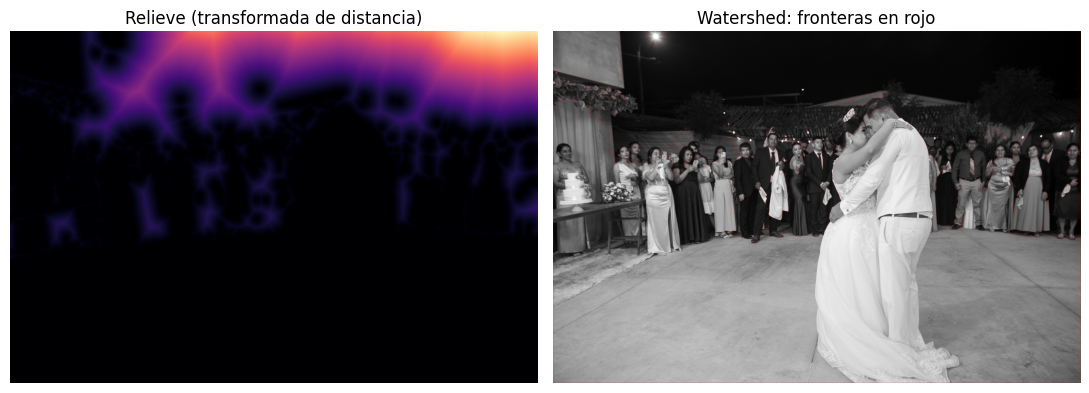

In [11]:
# 1) Binarizamos con Otsu, pero INVERTIDO (THRESH_BINARY_INV): el objeto queda en blanco.
_, thr = cv2.threshold(work_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2) Limpiamos motas de ruido con una "apertura" morfológica (erosionar y luego dilatar).
kernel = np.ones((3, 3), np.uint8)                       # ventana 3x3 de unos
limpio = cv2.morphologyEx(thr, cv2.MORPH_OPEN, kernel, iterations=2)

# 3) FONDO seguro: dilatamos el objeto; lo que quede fuera es seguro que es fondo.
fondo_seguro = cv2.dilate(limpio, kernel, iterations=3)

# 4) FRENTE seguro: la transformada de distancia mide, en cada píxel del objeto,
#    qué tan lejos está del fondo. Los centros (más lejos) son "seguro objeto".
dist = cv2.distanceTransform(limpio, cv2.DIST_L2, 5)
_, frente_seguro = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)   # nos quedamos con los centros
frente_seguro = np.uint8(frente_seguro)

# 5) Lo DESCONOCIDO es lo que no es ni frente ni fondo seguros (la zona de frontera).
desconocido = cv2.subtract(fondo_seguro, frente_seguro)

# 6) Etiquetamos cada objeto con un número distinto (connectedComponents).
_, marcadores = cv2.connectedComponents(frente_seguro)
marcadores = marcadores + 1                              # +1 para reservar el 0
marcadores[desconocido == 255] = 0                       # la zona desconocida se marca con 0

# 7) cv2.watershed "inunda" desde los marcadores y traza las fronteras, marcándolas con -1.
marcadores = cv2.watershed(work_bgr.copy(), marcadores)
resultado = work_rgb.copy()
resultado[marcadores == -1] = [255, 0, 0]                # pintamos las fronteras de rojo

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(dist, cmap="magma"); ax[0].set_title("Relieve (transformada de distancia)"); ax[0].axis("off")
ax[1].imshow(resultado);          ax[1].set_title("Watershed: fronteras en rojo"); ax[1].axis("off")
plt.tight_layout(); plt.show()

> Watershed brilla cuando hay varios objetos pegados (monedas, células, granos). Sobre una foto cualquiera las fronteras pueden salir algo caprichosas: lo importante es entender la **idea** de inundar desde marcadores.

---

## Parte 9 — El puente: característica diseñada vs aprendida

Todo lo de hoy comparte una receta: **una persona decidió qué mirar**. Comparémoslo con lo que hará una CNN.

Kernel al azar:
 [[ 0.13 -0.13  0.64]
 [ 0.1  -0.54  0.36]
 [ 1.3   0.95 -0.7 ]]


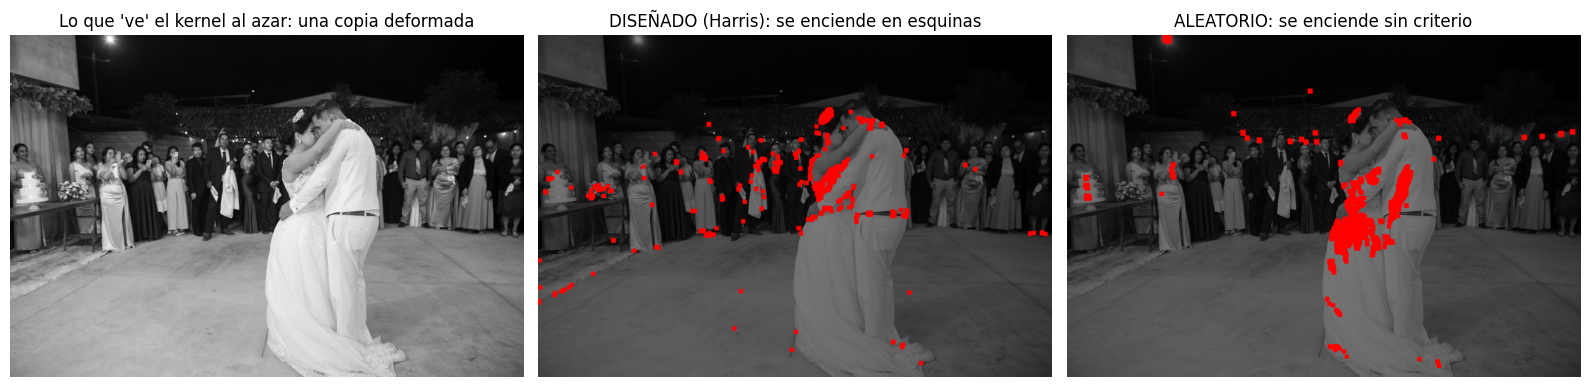

Harris se enciende en las esquinas porque lo diseñamos para eso.
El kernel al azar solo devuelve una versión deformada de la foto y se enciende donde le toca por casualidad, casi siempre en lo más claro.
Entrenar una CNN es ir corrigiendo esos 9 números hasta que se enciendan justo en lo que importa.


In [12]:
# Vamos a hacerle la MISMA pregunta a dos filtros: ¿en qué partes de la foto te "enciendes" con más fuerza?
# Y marcaremos en rojo esas zonas sobre tu foto.

# Suavizamos un poco la foto para que el grano no cuente como "esquinitas"
gris_suave = cv2.GaussianBlur(work_gray, (5, 5), 0)

# --- Filtro DISEÑADO: Harris, que construimos a propósito para detectar esquinas ---
resp_harris = cv2.cornerHarris(np.float32(gris_suave), 2, 3, 0.04)   # un número por píxel: cuán esquina es

# --- Filtro ALEATORIO: 9 números al azar, como un kernel de una CNN antes de entrenar ---
rng = np.random.default_rng(0)                                  # generador de azar (semilla fija = reproducible)
kernel_azar = rng.standard_normal((3, 3)).astype(np.float32)    # los 9 números del kernel, al azar
resp_azar = cv2.filter2D(np.float32(gris_suave), -1, kernel_azar)  # deslizamos ese kernel por la foto
print("Kernel al azar:\n", np.round(kernel_azar, 2))

def marcar(mascara):
    # mascara: 1 donde el filtro se enciende fuerte, 0 en el resto
    # engordamos los puntos para que se vean aunque la foto sea grande
    k = max(3, (min(work_gray.shape) // 80) | 1)               # tamaño del "pincel", siempre impar
    mascara = cv2.dilate(mascara, np.ones((k, k), np.uint8))
    # base: tu foto en grises y oscurecida, para que el rojo resalte
    base = cv2.cvtColor(work_gray, cv2.COLOR_GRAY2RGB) // 2
    base[mascara == 1] = [255, 0, 0]                            # pintamos de rojo donde se enciende
    return base

# Harris: el mismo criterio de la Parte 3, esquinas con más del 1 % de la respuesta máxima
fuerte_harris = np.uint8(resp_harris > 0.01 * resp_harris.max())
# Kernel al azar: el 0.5 % de píxeles con la respuesta más alta (np.percentile encuentra ese corte)
fuerte_azar = np.uint8(resp_azar >= np.percentile(resp_azar, 99.5))

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(cv2.normalize(resp_azar, None, 0, 1, cv2.NORM_MINMAX), cmap="gray")
ax[0].set_title("Lo que 've' el kernel al azar: una copia deformada")
ax[1].imshow(marcar(fuerte_harris))
ax[1].set_title("DISEÑADO (Harris): se enciende en esquinas")
ax[2].imshow(marcar(fuerte_azar))
ax[2].set_title("ALEATORIO: se enciende sin criterio")
for a in ax: a.axis("off")                                      # quitamos los ejes de los tres paneles
plt.tight_layout(); plt.show()

print("Harris se enciende en las esquinas porque lo diseñamos para eso.")
print("El kernel al azar solo devuelve una versión deformada de la foto y se enciende donde le toca por casualidad, casi siempre en lo más claro.")
print("Entrenar una CNN es ir corrigiendo esos 9 números hasta que se enciendan justo en lo que importa.")

**Este es el cierre de la Unidad 1.** Durante cuatro clases *diseñaste* la mirada: operaste píxeles, filtraste, sacaste bordes, describiste esquinas y segmentaste. Todo a mano. Desde la próxima clase, dejamos de diseñar los filtros y empezamos a **enseñárselos a una red**: esa es la Unidad 2.

---

## Parte 10 — TU TURNO: describe y segmenta tu imagen

Completa cada paso sobre tu propia foto. Reemplaza cada `None` por el código de la parte correspondiente (puedes copiarlo de arriba y adaptarlo).

Píxeles marcados como esquina: 2651
Puntos encontrados por ORB: 1000


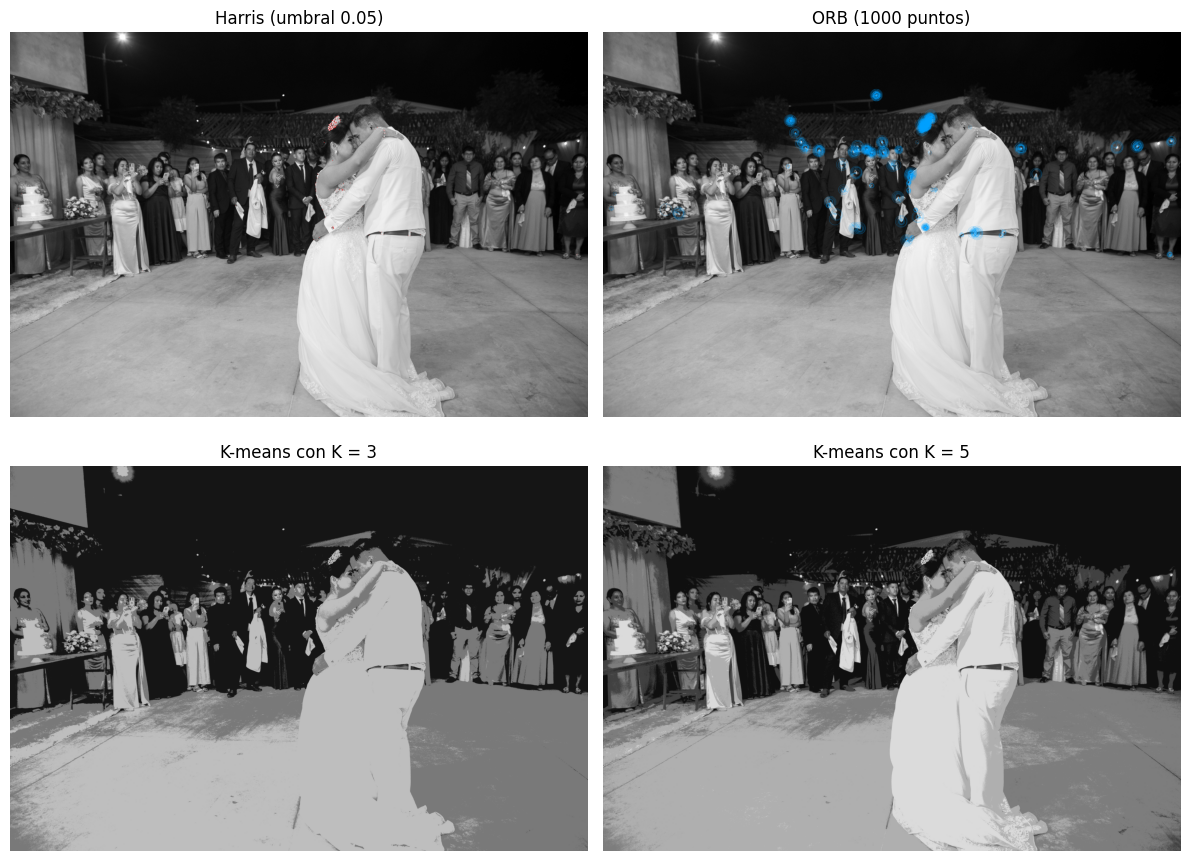

In [15]:
# ================================================================
# TU TURNO: describe y segmenta TU imagen (work_gray / work_rgb)
# El código ya está completo. Tu trabajo es cambiar los 4 valores
# de abajo, volver a ejecutar la celda y observar qué cambia.
# ================================================================

UMBRAL_HARRIS = 0.05   # <-- CAMBIA ESTO. Prueba 0.01 y luego 0.05: ¿salen más o menos esquinas?
PUNTOS_ORB    = 1000    # <-- CAMBIA ESTO. Prueba 100 y luego 1000: ¿dónde se concentran los puntos?
K_1           = 3      # <-- CAMBIA ESTO. Primer número de grupos de color
K_2           = 5      # <-- CAMBIA ESTO. Segundo número, para comparar con el primero

# ---------- Paso 1: esquinas con Harris (igual que en la Parte 3) ----------
resp = cv2.cornerHarris(np.float32(work_gray), 2, 3, 0.04)   # un número por píxel: cuán esquina es
resp = cv2.dilate(resp, None)                                 # engorda los puntos para que se vean
mis_esquinas = work_rgb.copy()                                # copia para no tocar tu foto original
fuertes = resp > UMBRAL_HARRIS * resp.max()                   # True donde la respuesta supera el umbral
mis_esquinas[fuertes] = [255, 0, 0]                           # esos píxeles se pintan de rojo
print("Píxeles marcados como esquina:", int(fuertes.sum()))

# ---------- Paso 2: puntos clave con ORB (igual que en la Parte 4) ----------
orb = cv2.ORB_create(nfeatures=PUNTOS_ORB)                    # pedimos hasta PUNTOS_ORB puntos
kp, des = orb.detectAndCompute(work_gray, None)               # kp = los puntos, des = sus huellas
mis_keypoints = cv2.drawKeypoints(work_rgb, kp, None, color=(0, 160, 255),
                                  flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)  # círculo + orientación
print("Puntos encontrados por ORB:", len(kp))

# ---------- Paso 3: segmentación por color con K-means (igual que en la Parte 7) ----------
def segmentar(K):
    Z = work_rgb.reshape((-1, 3)).astype(np.float32)          # la foto como lista de píxeles (R, G, B)
    criterio = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)   # cuándo parar
    _, etiquetas, centros = cv2.kmeans(Z, K, None, criterio, 5, cv2.KMEANS_RANDOM_CENTERS)
    return np.uint8(centros)[etiquetas.flatten()].reshape(work_rgb.shape)     # cada píxel toma el color de su grupo

seg_1 = segmentar(K_1)
seg_2 = segmentar(K_2)

# ---------- Paso 4: mostramos los cuatro resultados juntos ----------
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
ax[0, 0].imshow(mis_esquinas);  ax[0, 0].set_title(f"Harris (umbral {UMBRAL_HARRIS})")
ax[0, 1].imshow(mis_keypoints); ax[0, 1].set_title(f"ORB ({len(kp)} puntos)")
ax[1, 0].imshow(seg_1);         ax[1, 0].set_title(f"K-means con K = {K_1}")
ax[1, 1].imshow(seg_2);         ax[1, 1].set_title(f"K-means con K = {K_2}")
for fila in ax:
    for a in fila: a.axis("off")                              # quitamos los ejes de los cuatro paneles
plt.tight_layout(); plt.show()

### Paso 5 — Tu respuesta (escribe aquí)

**Pregunta:** Todas las técnicas de hoy (Harris, SIFT, HOG, K-means, watershed) tienen algo en común. ¿Qué es, y qué reemplaza una CNN de todo este trabajo cuando entramos a la Unidad 2?

*Escribe tu respuesta en una o dos frases:*

>  En mi foto se nota el límite: Harris solo marcó la tiara y el encaje, Otsu y K-means tienen similitud debido a que distorsiona la imagen y las figuras de la pareja debido al brillo que se enlaza con el piso, y watershed solo separó el cielo. Una CNN reemplaza ese diseño manual, porque aprende sola sus filtros a partir de los datos y puede distinguir objetos como las personas.

---

## Cierre

Cerraste la **Unidad 1** con el ciclo completo del dato visual: de la imagen como matriz de números, a operarla píxel a píxel, a filtrarla y sacar bordes, y hoy a describir sus puntos y partirla en regiones —todo con características que **tú diseñaste**—.

La próxima clase empieza la **Unidad 2**: tensores, PyTorch y tu primer modelo entrenado. Ahí la operación de fondo seguirá siendo la convolución que ya conoces; la diferencia es que la red **aprenderá sus propios filtros y descriptores** a partir de los datos, en lugar de que los diseñemos a mano.

*El último eslabón hecho a mano queda cerrado. Desde aquí, le enseñamos a la máquina a mirar.*